In [321]:
import cv2 as cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pandas

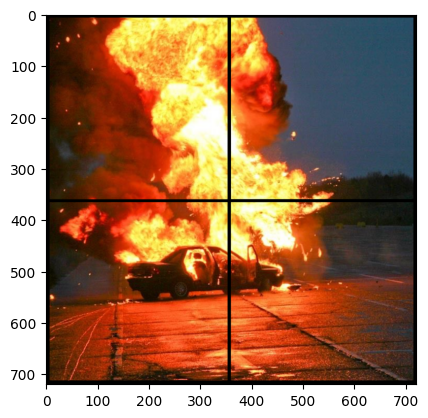

In [322]:
meledak = plt.imread('Assets/Meledak.PNG')
plt.imshow(meledak)
plt.show()

In [323]:
def fungsi_empat_s(gambar, a, b, c, d, mode='H'): 
    return gambar[a:b, c:d] if mode == 'H' else gambar[c:d, a:b]

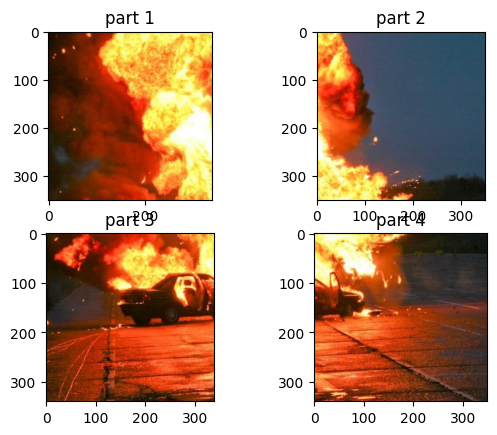

In [324]:
part1 = fungsi_empat_s(meledak, 10, 360, 10, 350, mode='H')
plt.subplot (2, 2, 1)
plt.imshow(part1, cmap='gray')
plt.title("part 1")

part2 = fungsi_empat_s(meledak, 10, 360, 360, 710, mode='H')
plt.subplot (2, 2, 2)
plt.imshow(part2, cmap='gray')
plt.title("part 2")

part3 = fungsi_empat_s(meledak, 370, 710, 10, 350, mode='H')
plt.subplot (2, 2, 3)
plt.imshow(part3, cmap='gray')
plt.title("part 3")

part4 = fungsi_empat_s(meledak, 370, 710, 360, 710, mode='H')
plt.subplot (2, 2, 4)
plt.imshow(part4, cmap='gray')
plt.title("part 4")

plt.show()

In [325]:
def merge_image(citra1, citra2, orientation='H'): 

    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), 
dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, 
citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], 
citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), 
dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, 
citra1.shape[2]), dtype=citra1.dtype) 
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 
0:citra2.shape[1]] = citra2 
    return gabungan 

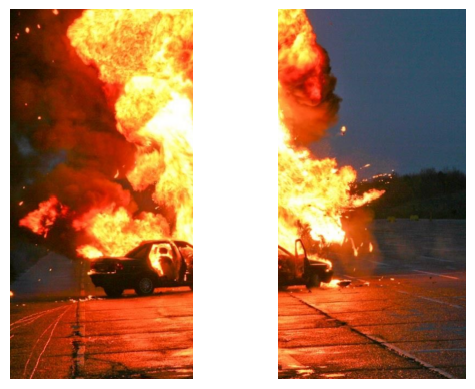

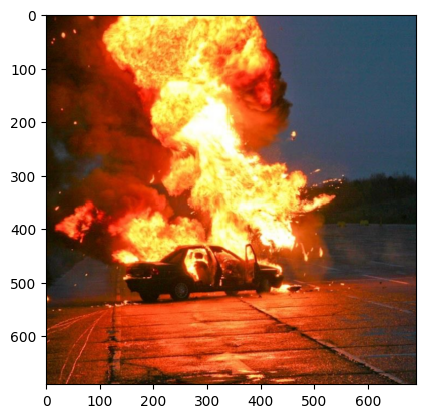

In [326]:
hasil_b = merge_image(part1, part3, orientation='v')
hasil_c = merge_image(part2, part4, orientation='v')
plt.subplot(1, 2, 1)
plt.imshow(hasil_b)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_c)
plt.axis('off')

plt.show()

hasil_akhir = merge_image(hasil_b, hasil_c, orientation='H')
plt.imshow(hasil_akhir)
plt.show()

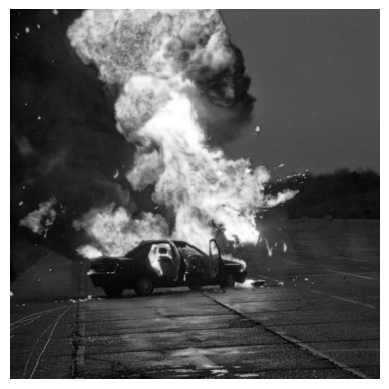

In [327]:
greyscale = cv2.cvtColor(hasil_akhir, cv2.COLOR_BGR2GRAY)
plt.imshow(greyscale, cmap='gray')
plt.axis('off')
plt.show()

In [328]:
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

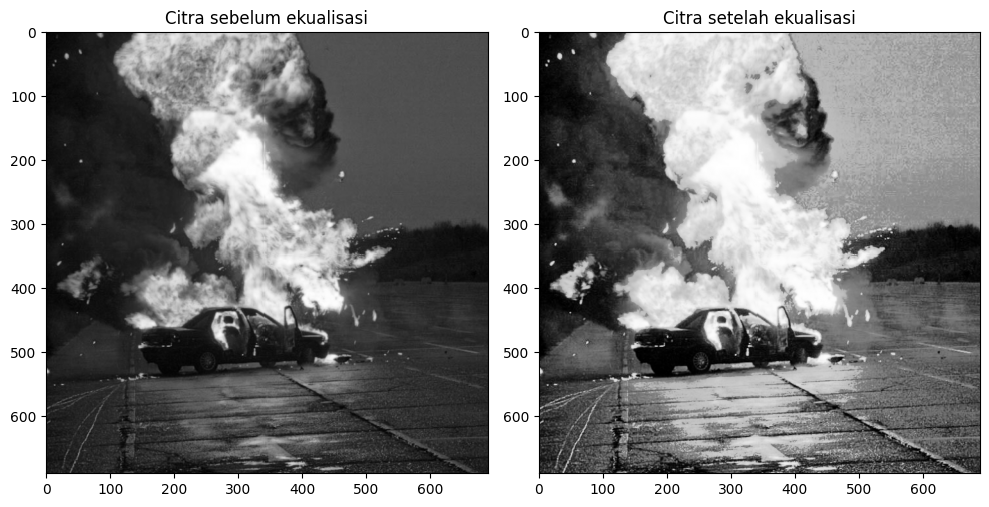

In [329]:
citra_gabung = (greyscale * 255).astype(np.uint8)

panjang, lebar = citra_gabung.shape
hasil_ekualisasi = ekualisasi_histogram(citra_gabung)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(citra_gabung, cmap='gray')
plt.title("Citra sebelum ekualisasi")
plt.subplot(1, 2, 2)
plt.imshow(hasil_ekualisasi, cmap='gray')
plt.title("Citra setelah ekualisasi")
plt.tight_layout()
plt.show()

In [330]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 
def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

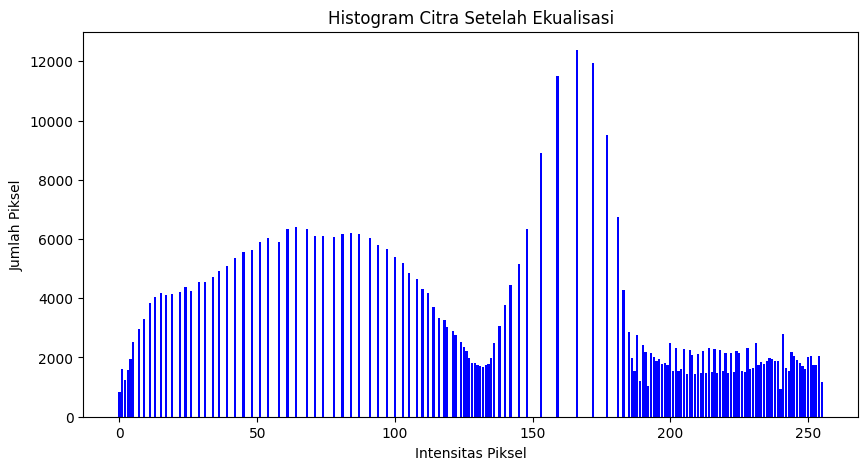

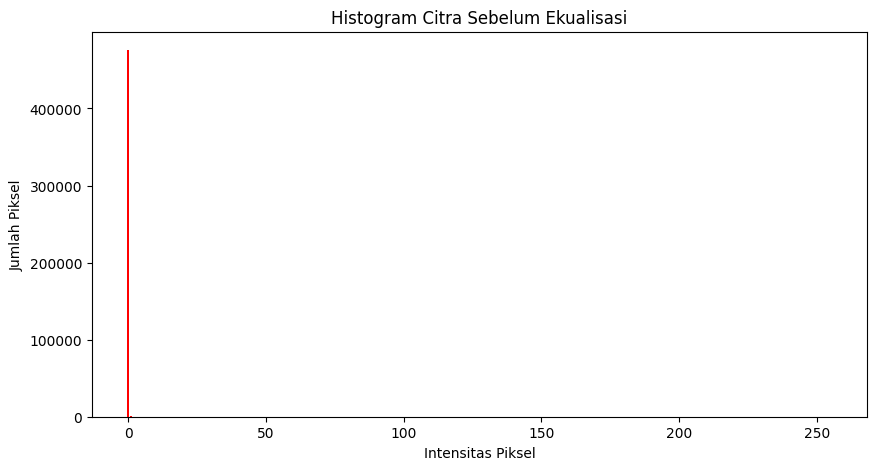

In [331]:
buat_hist(hasil_ekualisasi)
buat_hist(greyscale)
histogram_ekualisasi = buat_hist(hasil_ekualisasi)
histogram_greyscale = buat_hist(greyscale)
plot_histogram(histogram_ekualisasi,  "Histogram Citra Setelah Ekualisasi", "blue")
plot_histogram(histogram_greyscale, "Histogram Citra Sebelum Ekualisasi", "red")

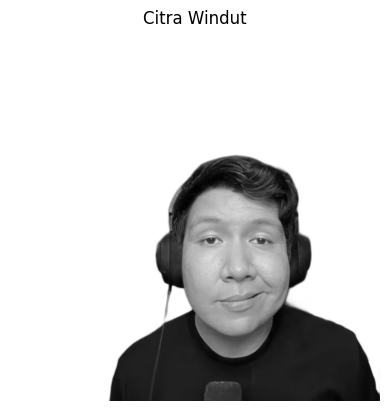

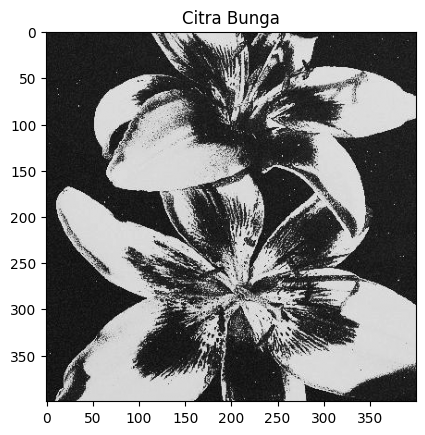

In [332]:
windut = cv2.imread('Assets/Windut.PNG', 0)
bunga = cv2.imread('Assets/Bunga.PNG', 0)

plt.title('A')
plt.imshow(windut, cmap='gray')
plt.axis('off')
plt.title('Citra Windut')
plt.show()

plt.imshow(bunga, cmap='gray')
plt.title('Citra Bunga')
plt.show()

In [333]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)
    for y in range(citra_asal.shape[0]):
        for x in range(citra_asal.shape[1]):
            pixel = citra_asal[y, x]
            hist_asal[pixel] += 1
    for y in range(citra_target.shape[0]):
        for x in range(citra_target.shape[1]):
            pixel = citra_target[y, x]
            hist_target[pixel] += 1
    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]
    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]
    map_hist = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        min_selisih = abs(cdf_asal[i] - cdf_target[0])
        indeks = 0
        for j in range(1, 256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < min_selisih:
                min_selisih = selisih
                indeks = j
        map_hist[i] = indeks
    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)
    for y in range(height):
        for x in range(width):
            pixel = citra_asal[y, x]
            hasil[y, x] = map_hist[pixel]
    return hasil

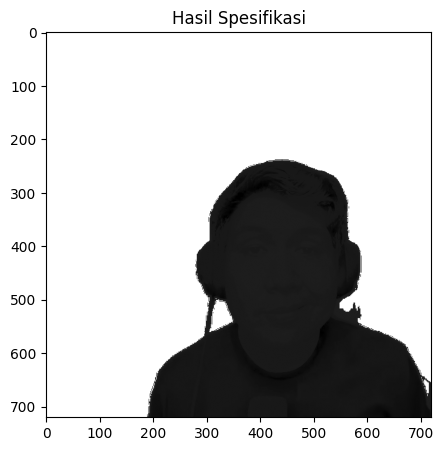

In [334]:
hasil_spesifikasi = spesifikasi_histogram(windut, bunga)
plt.figure(figsize=(12,5))
plt.imshow(hasil_spesifikasi, cmap='gray')
plt.title('Hasil Spesifikasi')
plt.show()

In [335]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 
def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

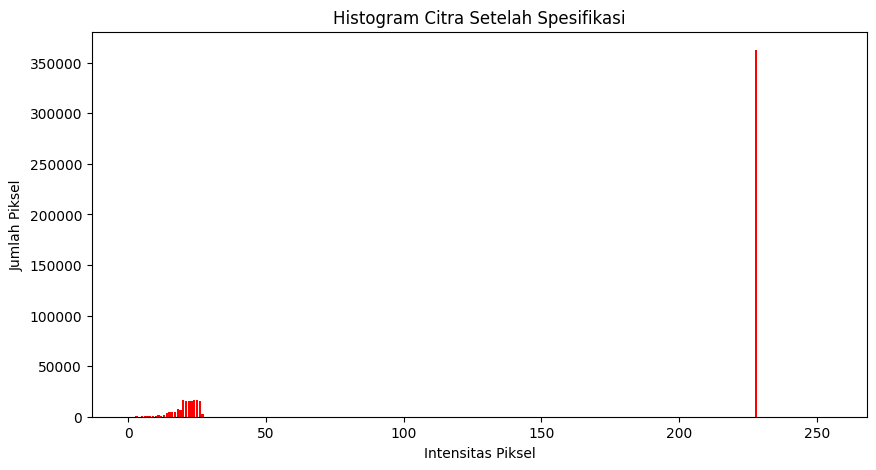

In [336]:
buat_hist(hasil_spesifikasi)
histogram_spesifikasi = buat_hist(hasil_spesifikasi)
plot_histogram(histogram_spesifikasi,  "Histogram Citra Setelah Spesifikasi", "red")